# Adaptive whitening with fast gain modulation and slow synaptic plasticity

Implementation and verification of Algorithm 1 from Duong et al. (NeurIPS 2023).

The algorithm factorizes the inverse whitening matrix as $\mathbf{M} = \alpha \mathbf{I}_N + \mathbf{W} \text{diag}(\mathbf{g}) \mathbf{W}^\top$ and performs online adaptive whitening via:
- **Fast gain modulation**: $\Delta g_i = \eta_g (z_i^2 - \|\mathbf{w}_i\|^2)$
- **Slow synaptic plasticity**: $\Delta \mathbf{w}_i = \eta_w (\mathbf{r} n_i - \mathbf{w}_i g_i)$
- **Neural dynamics** (solved at equilibrium): $\mathbf{r} = (\alpha \mathbf{I} + \mathbf{W} \text{diag}(\mathbf{g}) \mathbf{W}^\top)^{-1} \mathbf{s}$

In [125]:
import numpy as np
import torch
from torch.linalg import inv
import matplotlib.pyplot as plt
from tools import load, estimate_derivative, adap_whitening_2

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Verify `adap_whitening_2` implements Algorithm 1

Algorithm 1 from the paper has three components per timestep $t$:

1. **Neural dynamics** (iterated to convergence):
   - $\mathbf{z}_t = \mathbf{W}^\top \mathbf{r}_t$
   - $\mathbf{n}_t = \mathbf{g} \circ \mathbf{z}_t$
   - $\mathbf{r}_t \leftarrow \mathbf{r}_t + \eta_r (\mathbf{s}_t - \mathbf{W}\mathbf{n}_t - \alpha \mathbf{r}_t)$
   
   At equilibrium: $\mathbf{r} = (\alpha \mathbf{I} + \mathbf{W} \text{diag}(\mathbf{g}) \mathbf{W}^\top)^{-1} \mathbf{s}$

2. **Gains update**: $\mathbf{g} \leftarrow \mathbf{g} + \eta_g (\mathbf{z}_t \circ \mathbf{z}_t - \text{diag}(\mathbf{W}^\top \mathbf{W}))$

3. **Synaptic weights update**: $\mathbf{W} \leftarrow \mathbf{W} + \eta_w (\mathbf{r}_t \mathbf{n}_t^\top - \mathbf{W} \text{diag}(\mathbf{g}))$

The implementation computes the equilibrium response directly via matrix inversion instead of iterating recurrent dynamics.

### 1.1 Verify equilibrium neural dynamics

At convergence, the recurrent update $\mathbf{r} \leftarrow \mathbf{r} + \eta_r(\mathbf{s} - \mathbf{W}\mathbf{n} - \alpha\mathbf{r})$ implies $\mathbf{s} = \alpha \mathbf{r} + \mathbf{W} \text{diag}(\mathbf{g}) \mathbf{W}^\top \mathbf{r}$. We verify that the iterative dynamics converge to the closed-form solution.

In [126]:
torch.manual_seed(42)
N = 4
K = N * (N + 1) // 2
alpha = 1.0
eta_r = 0.01

W = torch.rand(N, K)
W = W / torch.norm(W, dim=0)
g = torch.randn(K) * 0.1
s = torch.randn(N)

# Closed-form equilibrium (as in adap_whitening_2)
M = alpha * torch.eye(N) + W @ torch.diag(g) @ W.T
r_exact = inv(M) @ s

# Iterative recurrent dynamics (Algorithm 1, steps 4-9)
r_iter = torch.zeros(N)
for _ in range(10000):
    z = W.T @ r_iter
    n = g * z
    r_iter = r_iter + eta_r * (s - W @ n - alpha * r_iter)

print(f'Closed-form r: {r_exact.numpy().round(6)}')
print(f'Iterative r:   {r_iter.numpy().round(6)}')
print(f'Max abs error:  {(r_exact - r_iter).abs().max().item():.2e}')
assert (r_exact - r_iter).abs().max().item() < 1e-4, 'Equilibrium mismatch!'
print('PASS: Iterative dynamics converge to closed-form solution.')

Closed-form r: [-0.111881  0.583059  0.080137  0.766933]
Iterative r:   [-0.11188   0.583057  0.080137  0.76693 ]
Max abs error:  2.56e-06
PASS: Iterative dynamics converge to closed-form solution.


### 1.2 Verify gain and weight updates match equations (7) and (8)

We run a single step of the algorithm manually and compare against `adap_whitening_2`.

In [127]:
torch.manual_seed(0)
N = 3
K = N * (N + 1) // 2  # = 6
lr_g = 0.01
lr_w = 0.001
alpha = 1.0

# Create a small dataset (single sample)
X = torch.randn(1, N)

# Run adap_whitening_2
Y, Z, g_stack, W_stack = adap_whitening_2(X.numpy(), lr_g=lr_g, lr_w=lr_w, alpha=alpha)

# Reproduce step-by-step using paper equations
# Reset seed and consume the same random state (randn for X) so that
# the subsequent torch.rand for W matches what adap_whitening_2 generates.
torch.manual_seed(0)
_ = torch.randn(1, N)  # advance RNG past X generation
W_manual = torch.rand(N, K)
W_manual = W_manual / torch.norm(W_manual, dim=0)
g_manual = torch.zeros(K)

x = X[0]

# Step 1: Neural dynamics at equilibrium
M = alpha * torch.eye(N) + W_manual @ torch.diag(g_manual) @ W_manual.T
r = inv(M) @ x

# Step 2: Interneuron inputs
z = W_manual.T @ r

# Step 3: Gain update (Eq. 7): Δg = η_g * (z² - diag(W⊤W))
g_manual_new = g_manual + lr_g * (z * z - torch.diag(W_manual.T @ W_manual))

# Step 4: Synaptic weight update (Eq. 8, vectorized):
# W ← W + η_w * (r nᵀ - W diag(g))
# where n = g ∘ z (gain-modulated interneuron outputs)
n = g_manual_new * z  # Note: code uses updated g for W update
W_manual_new = W_manual + lr_w * (r.reshape(-1, 1) @ n.reshape(1, -1) - W_manual @ torch.diag(g_manual_new))

# Compare
print('Response r:')
print(f'  Function: {Y[0].numpy().round(6)}')
print(f'  Manual:   {r.numpy().round(6)}')
assert torch.allclose(Y[0], r, atol=1e-5), 'Response mismatch!'

print('\nInterneuron inputs z:')
print(f'  Function: {Z[0].numpy().round(6)}')
print(f'  Manual:   {z.numpy().round(6)}')
assert torch.allclose(Z[0], z, atol=1e-5), 'z mismatch!'

print('\nGains g (after update):')
print(f'  Function: {g_stack[0].numpy().round(6)}')
print(f'  Manual:   {g_manual_new.numpy().round(6)}')
assert torch.allclose(g_stack[0], g_manual_new, atol=1e-5), 'Gains mismatch!'

print('\nWeights W (after update):')
print(f'  Max diff: {(W_stack[0] - W_manual_new).abs().max().item():.2e}')
assert torch.allclose(W_stack[0], W_manual_new, atol=1e-5), 'Weights mismatch!'

print('\nPASS: All update rules match the paper.')

Response r:
  Function: [ 1.540996 -0.293429 -2.17879 ]
  Manual:   [ 1.540996 -0.293429 -2.17879 ]

Interneuron inputs z:
  Function: [-0.997984 -0.954768 -0.608098 -1.21506  -2.060074 -1.596779]
  Manual:   [-0.997984 -0.954768 -0.608098 -1.21506  -2.060074 -1.596779]

Gains g (after update):
  Function: [-4.0000e-05 -8.8400e-04 -6.3020e-03  4.7640e-03  3.2439e-02  1.5497e-02]
  Manual:   [-4.0000e-05 -8.8400e-04 -6.3020e-03  4.7640e-03  3.2439e-02  1.5497e-02]

Weights W (after update):
  Max diff: 0.00e+00

PASS: All update rules match the paper.


### 1.3 Verify whitening on synthetic data with known covariance

Generate correlated Gaussian data and verify that the output covariance approaches identity.

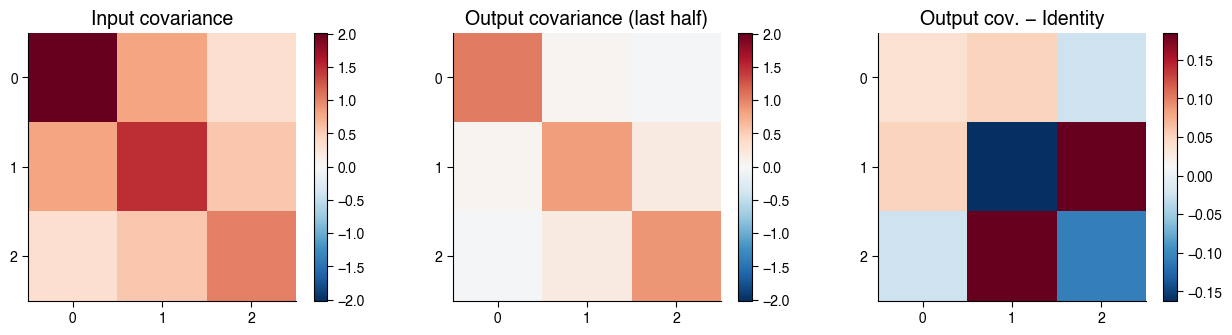

In [128]:
np.random.seed(42)
N = 3
T = 10000

# Generate correlated data with known covariance
C_true = np.array([[2.0, 0.8, 0.3],
                    [0.8, 1.5, 0.5],
                    [0.3, 0.5, 1.0]])
L = np.linalg.cholesky(C_true)
X_synth = (L @ np.random.randn(N, T)).T  # (T, N)

Y_synth, Z_synth, g_synth, W_synth = adap_whitening_2(
    X_synth, lr_g=0.01, lr_w=1e-5, alpha=1.0
)

# Check output covariance over the last portion (after convergence)
Y_np = Y_synth.numpy()
C_in = np.cov(X_synth.T)
C_out = np.cov(Y_np[-T//2:].T)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

vmax = max(np.abs(C_in).max(), np.abs(C_out).max())
im0 = axes[0].imshow(C_in, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Input covariance')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(C_out, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Output covariance (last half)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(C_out - np.eye(N), cmap='RdBu_r', aspect='equal')
axes[2].set_title('Output cov. − Identity')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))

plt.tight_layout()
plt.show()

### 1.4 Whitening error over time

Measure the operator-norm error $\|\mathbf{M}^{-1} \mathbf{C}_{ss} \mathbf{M}^{-1} - \mathbf{I}_N\|_{\text{op}}$ as in the paper (Eq. 9).

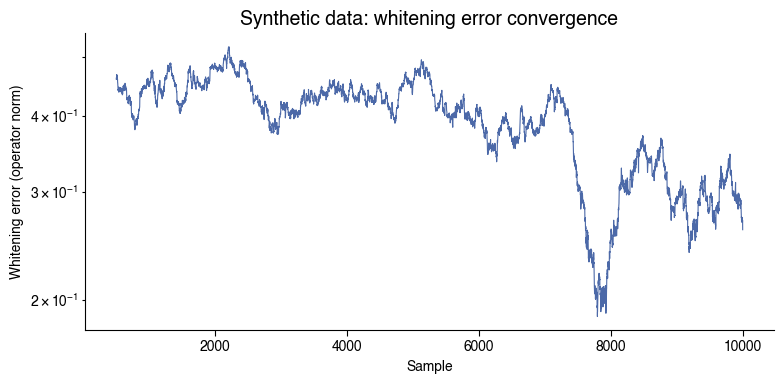

In [129]:
# Compute whitening error over time using sliding window covariance of outputs
window = 500
errors = []
for t in range(window, T):
    C_local = np.cov(Y_np[t-window:t].T)
    err = np.linalg.norm(C_local - np.eye(N), ord=2)
    errors.append(err)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(window, T), errors, lw=0.8)
ax.set_xlabel('Sample')
ax.set_ylabel('Whitening error (operator norm)')
ax.set_title('Synthetic data: whitening error convergence')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 2. Apply to sensor data

In [130]:
sensor_data, sequence, times_sec, sequence_sec = load('mix_100_20_1', reduced=True)
print(f'Sensor data shape: {sensor_data.shape}')
print(f'Number of sensors (reduced): {sensor_data.shape[1]}')
print(f'Number of timesteps: {sensor_data.shape[0]}')

Sensor data shape: (11445, 8)
Number of sensors (reduced): 8
Number of timesteps: 11445


In [131]:
# Normalize sensor data to [0, 1] per channel, then center
col_min = np.min(sensor_data, axis=0, keepdims=True)
col_max = np.max(sensor_data, axis=0, keepdims=True)
denom = col_max - col_min
denom[denom == 0] = 1.
x_norm = (sensor_data - col_min) / denom
x_norm = x_norm - x_norm.mean(axis=0)

# Add backward difference derivatives up to order 5
# Order n: Δⁿx[t] = Σ_{k=0}^{n} (-1)^k C(n,k) x[t-k]
from scipy.special import comb

max_order = 5
derivatives = []
for n in range(1, max_order + 1):
    coeffs = np.array([(-1)**k * comb(n, k, exact=True) for k in range(n + 1)])
    d = np.zeros_like(x_norm)
    for k, c in enumerate(coeffs):
        d[n:] += c * x_norm[n - k:len(x_norm) - k]
    d[:n] = 0  # not enough history for first n samples
    derivatives.append(d)

x_dense = np.hstack([x_norm] + derivatives)

# Trim leading rows where derivatives are undefined
x_dense = x_dense[max_order:]

n_base = x_norm.shape[1]
print(f'Base channels: {n_base}')
print(f'With derivatives (orders 1-{max_order}): {x_dense.shape[1]} channels, {x_dense.shape[0]} samples')

Base channels: 8
With derivatives (orders 1-5): 48 channels, 11440 samples


### Grid search over learning rates

In [132]:
lr_g_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
lr_w_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

n_sensors = x_dense.shape[1]
last_half = x_dense.shape[0] // 2
results = np.full((len(lr_g_values), len(lr_w_values)), np.inf)

for i, lr_g in enumerate(lr_g_values):
    for j, lr_w in enumerate(lr_w_values):
        try:
            Y, _, _, _ = adap_whitening_2(
                x_dense, lr_g=lr_g, lr_w=lr_w, alpha=1.0, K_constrained=True
            )
            Y_np = Y.numpy()
            if np.isnan(Y_np).any():
                continue
            C_out = np.cov(Y_np[-last_half:].T)
            results[i, j] = np.linalg.norm(C_out - np.eye(n_sensors), ord=2)
        except Exception:
            continue
        print(f'lr_g={lr_g:.0e}, lr_w={lr_w:.0e} → error={results[i,j]:.4f}')

best_idx = np.unravel_index(np.argmin(results), results.shape)
best_lr_g = lr_g_values[best_idx[0]]
best_lr_w = lr_w_values[best_idx[1]]
print(f'\nBest: lr_g={best_lr_g:.0e}, lr_w={best_lr_w:.0e}, error={results[best_idx]:.4f}')

lr_g=1e-04, lr_w=1e-07 → error=1.0000
lr_g=1e-04, lr_w=1e-06 → error=1.0000
lr_g=1e-04, lr_w=1e-05 → error=1.0000
lr_g=1e-04, lr_w=1e-04 → error=1.0000
lr_g=5e-04, lr_w=1e-07 → error=18.7303
lr_g=5e-04, lr_w=1e-06 → error=140.8128
lr_g=5e-04, lr_w=1e-05 → error=29.3794
lr_g=1e-03, lr_w=1e-07 → error=64.4376
lr_g=5e-03, lr_w=1e-07 → error=137.3674
lr_g=1e-02, lr_w=1e-07 → error=118.9536

Best: lr_g=1e-04, lr_w=1e-06, error=1.0000


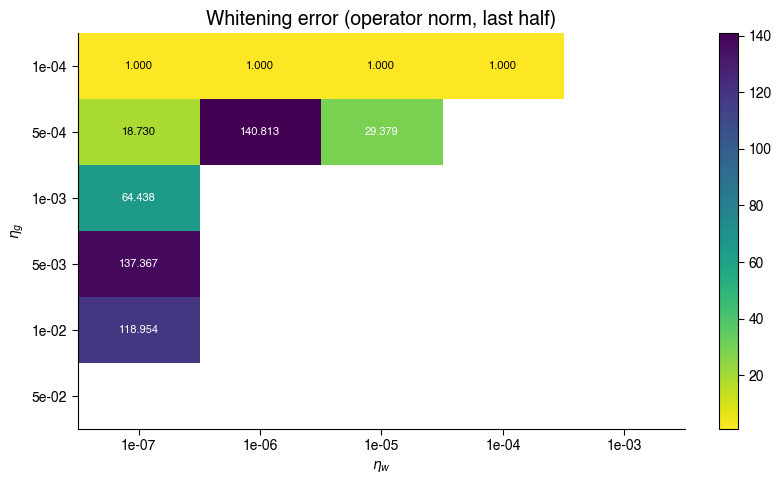

In [133]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(results, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(lr_w_values)))
ax.set_xticklabels([f'{v:.0e}' for v in lr_w_values])
ax.set_yticks(range(len(lr_g_values)))
ax.set_yticklabels([f'{v:.0e}' for v in lr_g_values])
ax.set_xlabel('$\\eta_w$')
ax.set_ylabel('$\\eta_g$')
ax.set_title('Whitening error (operator norm, last half)')

for i in range(len(lr_g_values)):
    for j in range(len(lr_w_values)):
        val = results[i, j]
        text = f'{val:.3f}' if np.isfinite(val) else 'NaN'
        color = 'w' if val > np.nanmedian(results[np.isfinite(results)]) else 'k'
        ax.text(j, i, text, ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [134]:
# Run adaptive whitening with best learning rates from grid search
Y_sens, Z_sens, g_sens, W_sens = adap_whitening_2(
    x_dense, lr_g=best_lr_g, lr_w=best_lr_w, alpha=1.0, K_constrained=True
)

Y_sens_np = Y_sens.numpy()
print(f'Using lr_g={best_lr_g:.0e}, lr_w={best_lr_w:.0e}')
print(f'Output shape: {Y_sens_np.shape}')
print(f'Any NaN: {np.isnan(Y_sens_np).any()}')

Using lr_g=1e-04, lr_w=1e-06
Output shape: (11440, 48)
Any NaN: False


## 3. Whitening assessment

### 3.1 Input vs output covariance matrices

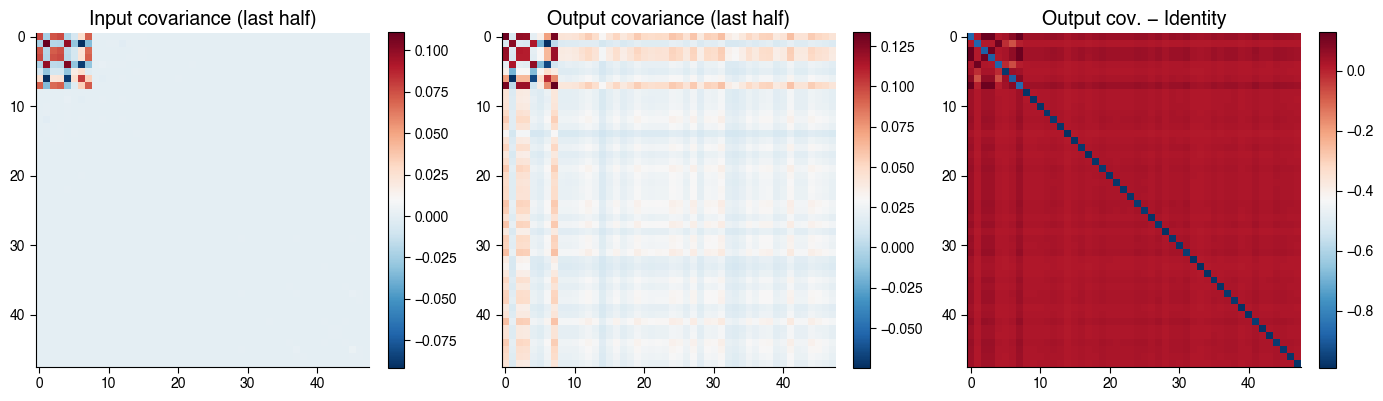

In [135]:
n_sensors = x_dense.shape[1]
T_sens = x_dense.shape[0]
last_half = T_sens // 2

C_input = np.cov(x_dense[-last_half:].T)
C_output = np.cov(Y_sens_np[-last_half:].T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(C_input, cmap='RdBu_r', aspect='equal')
axes[0].set_title('Input covariance (last half)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(C_output, cmap='RdBu_r', aspect='equal')
axes[1].set_title('Output covariance (last half)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(C_output - np.eye(n_sensors), cmap='RdBu_r', aspect='equal')
axes[2].set_title('Output cov. − Identity')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

### 3.2 Sensor traces before and after whitening

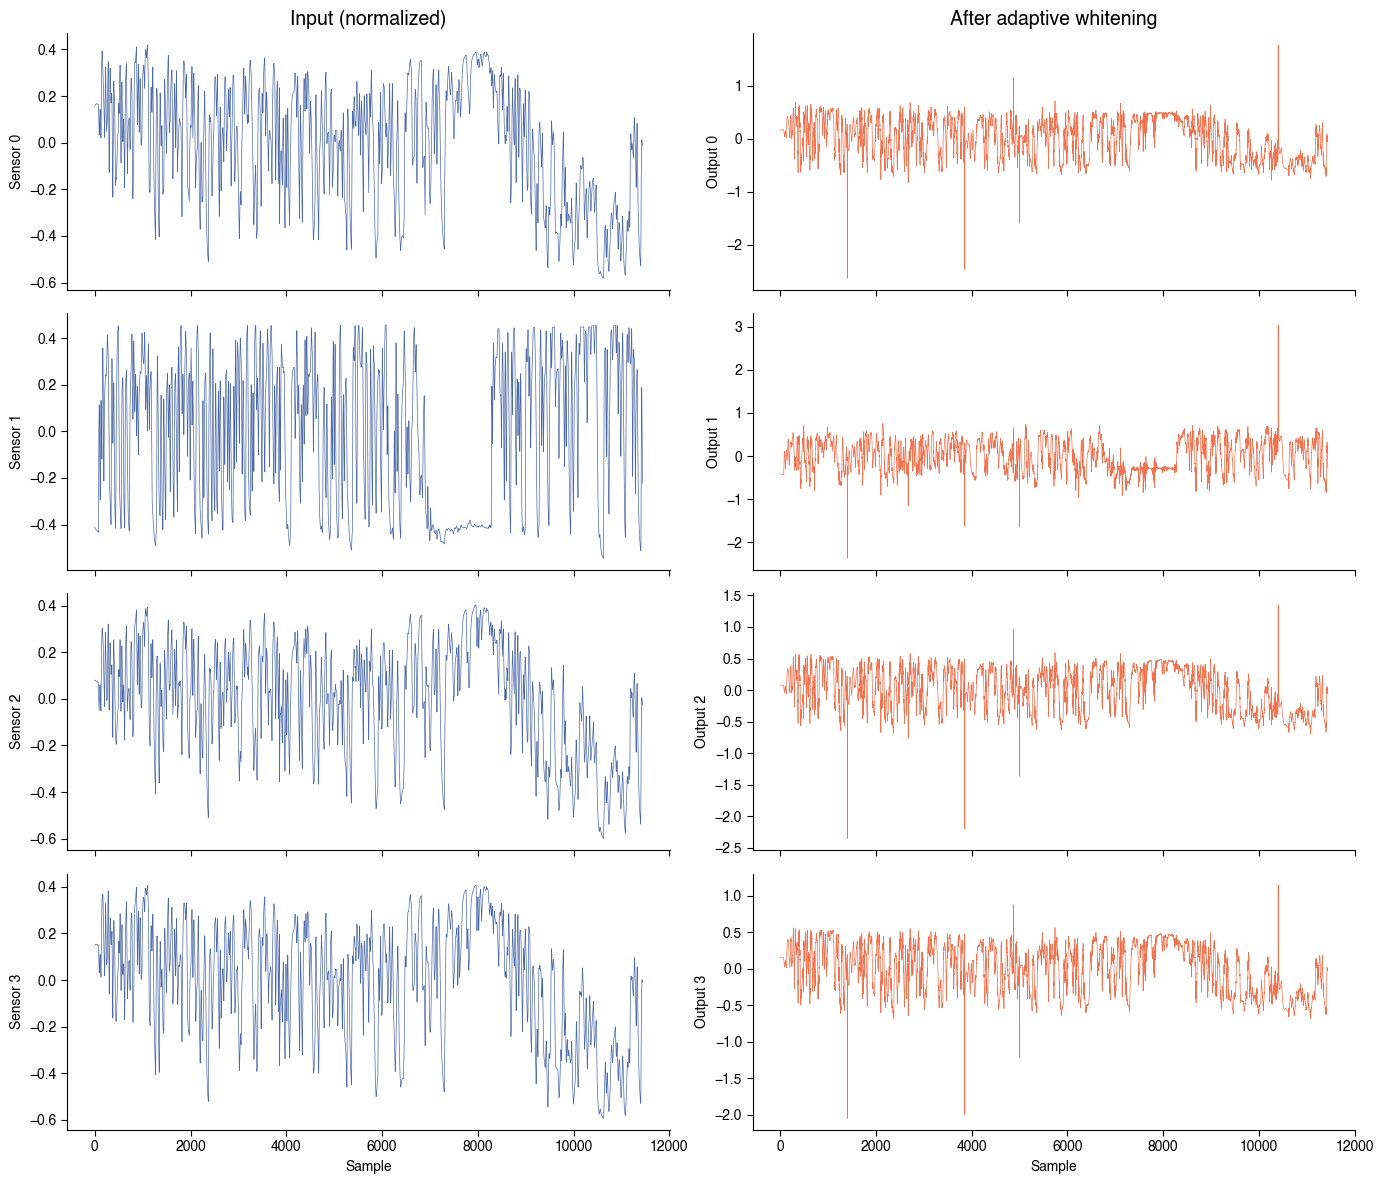

In [136]:
n_show = min(4, n_sensors)
fig, axes = plt.subplots(n_show, 2, figsize=(14, 3 * n_show), sharex=True)

for i in range(n_show):
    axes[i, 0].plot(x_dense[:, i], lw=0.5)
    axes[i, 0].set_ylabel(f'Sensor {i}')
    if i == 0:
        axes[i, 0].set_title('Input (normalized)')

    axes[i, 1].plot(Y_sens_np[:, i], lw=0.5, color='C1')
    axes[i, 1].set_ylabel(f'Output {i}')
    if i == 0:
        axes[i, 1].set_title('After adaptive whitening')

axes[-1, 0].set_xlabel('Sample')
axes[-1, 1].set_xlabel('Sample')
plt.tight_layout()
plt.show()

### 3.3 Variance per channel over time (sliding window)

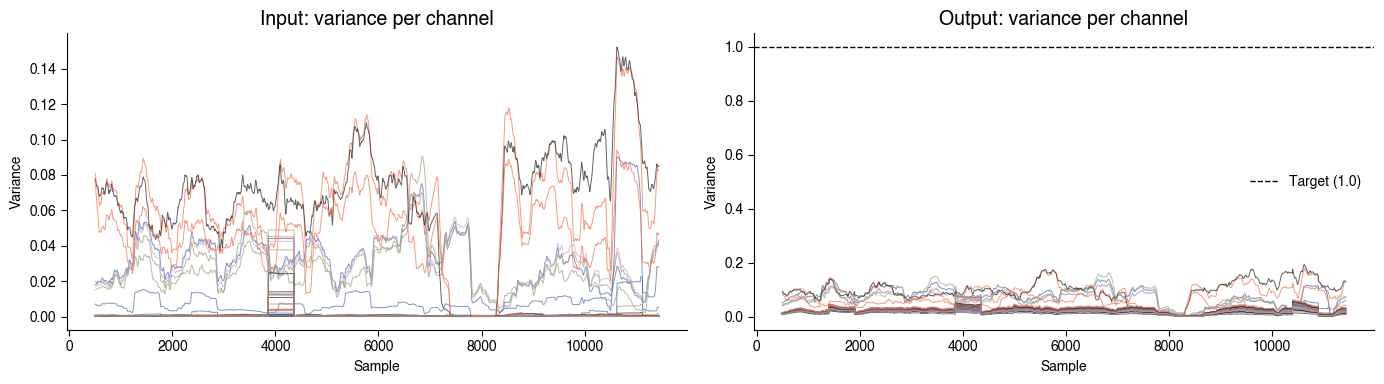

In [137]:
window = min(500, T_sens // 4)
var_input = np.array([x_dense[t-window:t].var(axis=0) for t in range(window, T_sens)])
var_output = np.array([Y_sens_np[t-window:t].var(axis=0) for t in range(window, T_sens)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in range(n_sensors):
    axes[0].plot(np.arange(window, T_sens), var_input[:, i], lw=0.7, alpha=0.7)
axes[0].set_title('Input: variance per channel')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Variance')

for i in range(n_sensors):
    axes[1].plot(np.arange(window, T_sens), var_output[:, i], lw=0.7, alpha=0.7)
axes[1].axhline(1.0, color='k', ls='--', lw=1, label='Target (1.0)')
axes[1].set_title('Output: variance per channel')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Cross-correlation before and after whitening

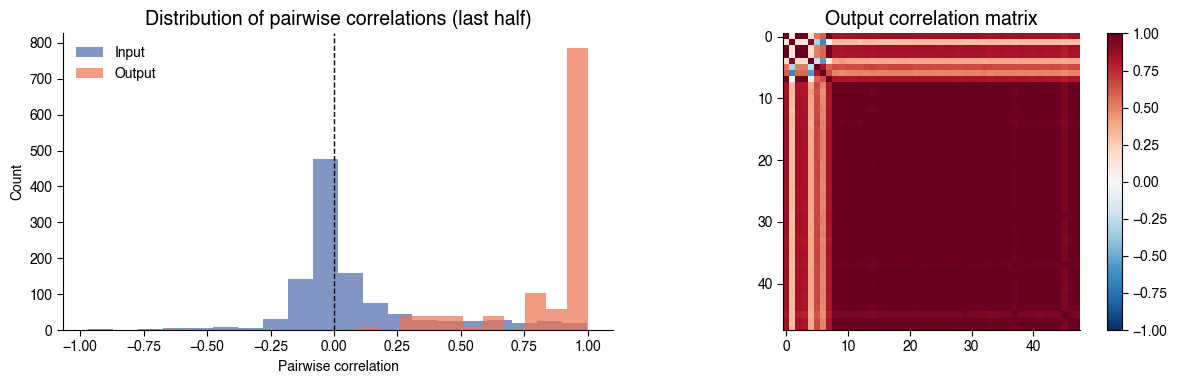

In [138]:
# Off-diagonal elements of the correlation matrix
corr_input = np.corrcoef(x_dense[-last_half:].T)
corr_output = np.corrcoef(Y_sens_np[-last_half:].T)

# Extract upper-triangular off-diagonal elements
mask = np.triu(np.ones((n_sensors, n_sensors), dtype=bool), k=1)
offdiag_in = corr_input[mask]
offdiag_out = corr_output[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(offdiag_in, bins=20, alpha=0.7, label='Input', color='C0')
axes[0].hist(offdiag_out, bins=20, alpha=0.7, label='Output', color='C1')
axes[0].axvline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Pairwise correlation')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of pairwise correlations (last half)')
axes[0].legend()

im = axes[1].imshow(corr_output, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
axes[1].set_title('Output correlation matrix')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

### 3.5 Gain and weight convergence

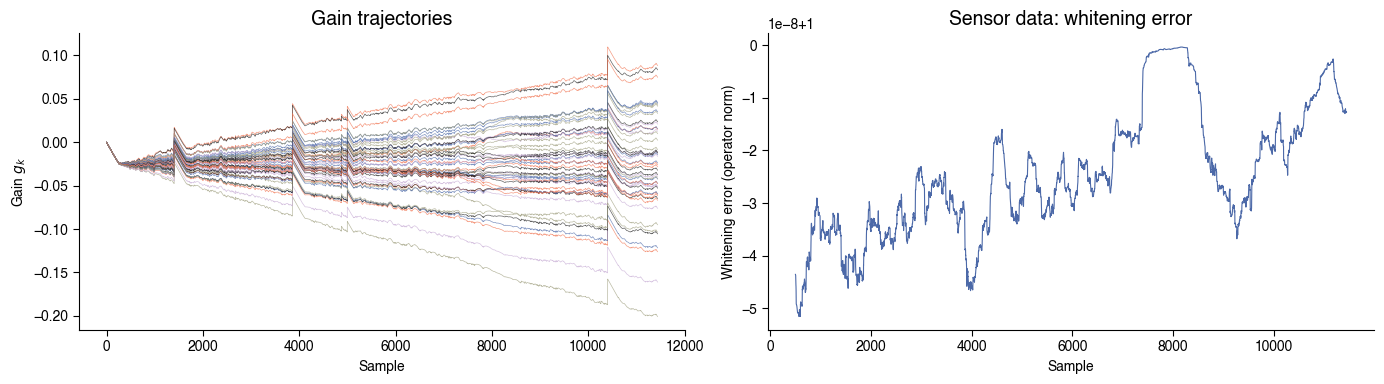

In [139]:
g_np = g_sens.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gains over time
for k in range(g_np.shape[1]):
    axes[0].plot(g_np[:, k], lw=0.5, alpha=0.7)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Gain $g_k$')
axes[0].set_title('Gain trajectories')

# Whitening error over time
window_err = min(500, T_sens // 4)
errors_sens = []
for t in range(window_err, T_sens):
    C_local = np.cov(Y_sens_np[t-window_err:t].T)
    err = np.linalg.norm(C_local - np.eye(n_sensors), ord=2)
    errors_sens.append(err)

axes[1].plot(np.arange(window_err, T_sens), errors_sens, lw=0.8)
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Whitening error (operator norm)')
axes[1].set_title('Sensor data: whitening error')

plt.tight_layout()
plt.show()

### 3.6 Eigenvalue spectrum of output covariance

Perfect whitening produces unit eigenvalues.

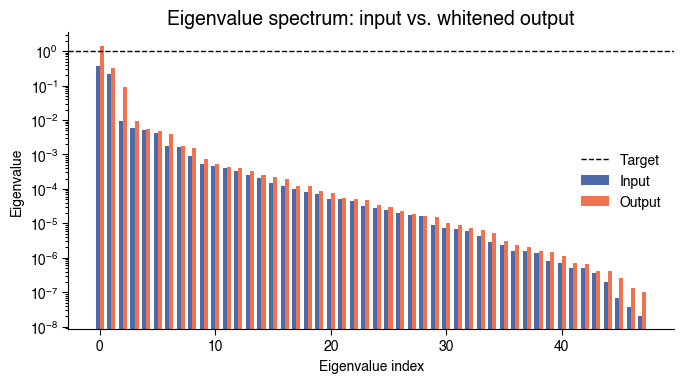

In [140]:
eigs_in = np.linalg.eigvalsh(C_input)
eigs_out = np.linalg.eigvalsh(C_output)

fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(n_sensors)
width = 0.35
ax.bar(x_pos - width/2, sorted(eigs_in, reverse=True), width, label='Input', color='C0')
ax.bar(x_pos + width/2, sorted(eigs_out, reverse=True), width, label='Output', color='C1')
ax.axhline(1.0, color='k', ls='--', lw=1, label='Target')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue spectrum: input vs. whitened output')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()